# 1. MLflow Tracking server configuration

In [36]:
# mlflow_connect.py
import mlflow
import warnings

warnings.filterwarnings("ignore")

def connect():
    mlflow.set_tracking_uri("http://localhost:5001")
    print("Connected to MLflow at:", mlflow.get_tracking_uri())

# 2. Automatic logging with scikit-learn

## 2.1 Dataset preparation

In [37]:
import numpy as np
import pandas as pd

from feature_engine.encoding import RareLabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [38]:
df = pd.read_parquet("data/ames_data_2006_2008.parquet")

df = df.sort_values(by=["Yr.Sold"])

# As we have temporal data, the best way to evaluate our model is time (chronological)
# split, where the newest data is used for testing. We will assume that we have the
# data #for years 2006 and 2007, and evaluate using data from 2008.

df_train = df[df["Yr.Sold"] < 2008]
df_test = df[df["Yr.Sold"] == 2008]

y_train = df_train.pop("SalePrice")
y_test = df_test.pop("SalePrice")

categorical_features = df_train.select_dtypes(include="object").columns
numerical_features = df_train.select_dtypes(exclude="object").columns

In [39]:
median_imputer = SimpleImputer(strategy="median")
min_max_scaler = MinMaxScaler()

rare_encoder = RareLabelEncoder(
    tol=0.01,
    n_categories=0,
    missing_values="ignore"
)

one_hot_encoder = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore"
)

num_pipeline = Pipeline(
    [("median_imputer", median_imputer), ("min_max_scaler", min_max_scaler)]
)

cat_pipeline = Pipeline(
    [("rare_encoder", rare_encoder), ("one_hot_encoder", one_hot_encoder)]
)

column_transformer = ColumnTransformer(
    [
        ("num_pipeline", num_pipeline, numerical_features),
        ("cat_pipeline", cat_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)

column_transformer.fit(df_train)

X_train = column_transformer.transform(df_train)
X_test = column_transformer.transform(df_test)

2026/04/09 23:07:14 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a5f8990bf6aa45b58bec7d14379df90e', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/09 23:07:14 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/04/09 23:07:14 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '718a63124a234437929f3bf671134c73', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/09 23:07:15 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


In [40]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1319
Test samples: 622
Number of features: 209


## 2.2 Training with MLflow autologging

In [41]:
mlflow.sklearn.autolog(
    log_input_examples=True, log_model_signatures=True, log_models=False, silent=False
)

mlflow.set_experiment("ames-housing-autolog")

<Experiment: artifact_location='file:///C:/Users/micha/PycharmProjects/lab5_01/mlruns/1', creation_time=1775765585590, experiment_id='1', last_update_time=1775765585590, lifecycle_stage='active', name='ames-housing-autolog', tags={}, trace_location=None, workspace='default'>

In [42]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = [
    ("Ridge Regression", Ridge()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

In [43]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test):
    results = {}

    for model_name, model in models:
        # start MLflow run - a unit grouping logs from different model runs
        # everything within this context manager will get logged as a run
        with mlflow.start_run(run_name=model_name):
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()

            # log additional custom metrics, in addition to autologging
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

In [44]:
fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)

2026/04/09 23:07:15 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 23:07:15 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Ridge Regression:
  RMSE: 31348.39
  MAE: 17303.38
  R^2: 0.828
  CV R^2 (mean ± std): 0.790 ± 0.122


2026/04/09 23:07:16 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Decision Tree:
  RMSE: 43089.82
  MAE: 25764.73
  R^2: 0.675
  CV R^2 (mean ± std): 0.717 ± 0.100


2026/04/09 23:07:16 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



K-Nearest Neighbors:
  RMSE: 37972.33
  MAE: 25638.13
  R^2: 0.747
  CV R^2 (mean ± std): 0.654 ± 0.073


2026/04/09 23:07:25 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Random Forest:
  RMSE: 26696.83
  MAE: 16195.06
  R^2: 0.875
  CV R^2 (mean ± std): 0.810 ± 0.091

Gradient Boosting:
  RMSE: 23642.10
  MAE: 14660.90
  R^2: 0.902
  CV R^2 (mean ± std): 0.822 ± 0.106


## 2.3 Connecting DVC and MLflow

In [45]:
import yaml

def get_dvc_metadata(dvc_file_path):
    with open(dvc_file_path, 'r') as f:
        dvc_data = yaml.safe_load(f)

    metadata = {
        'md5': dvc_data['outs'][0]['md5'],
        'size': dvc_data['outs'][0]['size'],
        'path': dvc_data['outs'][0]['path']
    }
    return metadata

dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')
print("DVC Metadata:")
print(f"MD5 hash: {dvc_metadata['md5']}")
print(f"File size: {dvc_metadata['size']} bytes")
print(f"Data path: {dvc_metadata['path']}")

DVC Metadata:
MD5 hash: 7f045b7f24d1af6daf02a075a188432d
File size: 186512 bytes
Data path: ames_data_2006_2008.parquet


In [46]:
def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test):
    results = {}

    dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')

    for model_name, model in models:
        with mlflow.start_run(run_name=model_name):

            mlflow.log_param("dvc_md5", dvc_metadata["md5"])
            mlflow.log_param("dvc_size", dvc_metadata["size"])
            mlflow.log_param("dvc_path", dvc_metadata["path"])

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()

            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")


1. Run 5 more experiments with different parameters and models from scikit-learn. You can use any supervised learning methods from scikit-learn. Find some other models or parameters to tune our current models with and run the experiments again.

In [47]:
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import ExtraTreesRegressor, AdaBoostRegressor

new_models = [
    ("Lasso", Lasso(alpha=0.001)),
    ("ElasticNet", ElasticNet(alpha=0.001, l1_ratio=0.5)),
    ("SVR", SVR(C=10, kernel="rbf")),
    ("Extra Trees", ExtraTreesRegressor(n_estimators=200, random_state=42)),
    ("AdaBoost", AdaBoostRegressor(n_estimators=200, random_state=42)),
]

fit_sklearn_models_with_cv(new_models, X_train, X_test, y_train, y_test)

2026/04/09 23:07:29 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/04/09 23:07:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Lasso:
  RMSE: 33623.31
  MAE: 17593.57
  R^2: 0.802
  CV R^2 (mean ± std): 0.711 ± 0.141


2026/04/09 23:07:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



ElasticNet:
  RMSE: 31795.88
  MAE: 17388.95
  R^2: 0.823
  CV R^2 (mean ± std): 0.779 ± 0.131


2026/04/09 23:07:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



SVR:
  RMSE: 76865.82
  MAE: 54457.62
  R^2: -0.036
  CV R^2 (mean ± std): -0.121 ± 0.142


2026/04/09 23:07:50 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Extra Trees:
  RMSE: 24404.64
  MAE: 15926.41
  R^2: 0.896
  CV R^2 (mean ± std): 0.798 ± 0.108

AdaBoost:
  RMSE: 34707.40
  MAE: 26280.90
  R^2: 0.789
  CV R^2 (mean ± std): 0.725 ± 0.087


3. Make sure you have included DVC metadata logging. You can initialize dvc_metadata by calling above defined get_dvc_metadata function with the .dvc metadata file. Then you can just for each experiment add param logging like:
mlflow.log_param("param_name", "value you want to log") # e.g md5

In [48]:
import yaml

def get_dvc_metadata(dvc_file_path):
    with open(dvc_file_path, 'r') as f:
        dvc_data = yaml.safe_load(f)

    metadata = {
        'md5': dvc_data['outs'][0]['md5'],
        'size': dvc_data['outs'][0]['size'],
        'path': dvc_data['outs'][0]['path']
    }
    return metadata

In [49]:
dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')

mlflow.log_param("dvc_md5", dvc_metadata["md5"])
mlflow.log_param("dvc_size", dvc_metadata["size"])
mlflow.log_param("dvc_path", dvc_metadata["path"])

'ames_data_2006_2008.parquet'

2. Use the function fit_sklearn_models_with_cv() created above, or you can write your own if you want.

In [50]:
def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test):
    results = {}

    dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')

    for model_name, model in models:
        with mlflow.start_run(run_name=model_name):

            mlflow.log_param("dvc_md5", dvc_metadata["md5"])
            mlflow.log_param("dvc_size", dvc_metadata["size"])
            mlflow.log_param("dvc_path", dvc_metadata["path"])

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()

            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

# 3. Manual logging with PyTorch

In [51]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold

# disable sklearn autologging!
mlflow.sklearn.autolog(disable=True)

mlflow.set_experiment("pytorch-housing-manual")

<Experiment: artifact_location='file:///C:/Users/micha/PycharmProjects/lab5_01/mlruns/2', creation_time=1775768704861, experiment_id='2', last_update_time=1775768704861, lifecycle_stage='active', name='pytorch-housing-manual', tags={}, trace_location=None, workspace='default'>

## 3.1 Targets transformation

<Axes: ylabel='Frequency'>

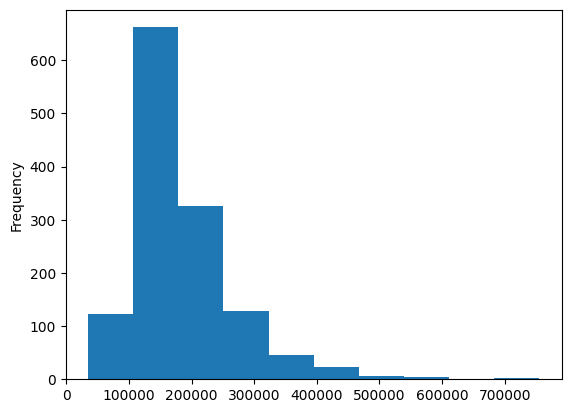

In [53]:
y_train.plot.hist()

<Axes: ylabel='Frequency'>

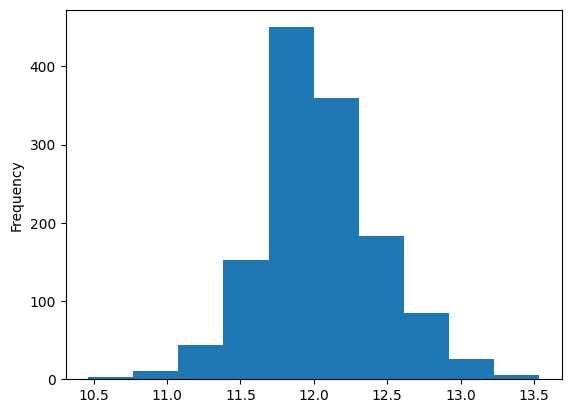

In [54]:
y_train_log = np.log1p(y_train)

pd.Series(y_train_log).plot.hist()

## 3.2 Define and train the model

In [55]:
class HousePriceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_rate=0.2):
        super(HousePriceNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [56]:
import torch.nn as nn


class PyTorchTrainer:
    def __init__(
        self, model_class: type[nn.Module], config: dict
    ):
        required_keys = ['hidden_units', 'dropout', 'batch_size', 'learning_rate',
                         'log_interval', 'epochs', 'name']
        missing = [key for key in required_keys if key not in config]
        if missing:
            raise ValueError(f"Missing required config keys: {missing}")

        self.model_class = model_class
        self.config = config

    def create_model(self, input_dim: int) -> nn.Module:
        return self.model_class(
            input_dim=input_dim,
            hidden_dim=self.config["hidden_units"],
            dropout_rate=self.config["dropout"],
        )

    def create_data_loader(
        self, X: torch.Tensor, y: torch.Tensor, shuffle: bool = True
    ) -> DataLoader:
        dataset = TensorDataset(X, y)
        return DataLoader(
            dataset, batch_size=self.config["batch_size"], shuffle=shuffle
        )

    def train_epoch(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        criterion: nn.Module,
        optimizer: optim.Optimizer,
    ) -> float:
        model.train()
        epoch_loss = 0.0
        batch_count = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batch_count += 1

        return epoch_loss / batch_count

    def train_model(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        epochs: int,
        metric_prefix: str = "",
    ) -> None:
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=self.config["learning_rate"])

        for epoch in range(epochs):
            avg_mse = self.train_epoch(model, train_loader, criterion, optimizer)

            if epoch % self.config["log_interval"] == 0:
                metric_name = (
                    f"{metric_prefix}train_mse" if metric_prefix else "train_mse"
                )
                # manually log metric value, with a given name and step value
                mlflow.log_metric(metric_name, avg_mse, step=epoch)

    @torch.no_grad()
    def evaluate_model(
        self,
        model: nn.Module,
        X: torch.Tensor,
        y_test: torch.Tensor,
        log_prefix: str = "",
    ) -> dict[str, float]:
        model.eval()

        y_pred_norm = model(X)

        # revert the logarithm with exponent
        y_pred = np.expm1(y_pred_norm.numpy())
        y_test = y_test.numpy()

        rmse = root_mean_squared_error(y_test.ravel(), y_pred.ravel())
        mae = mean_absolute_error(y_test.ravel(), y_pred.ravel())
        r2 = r2_score(y_test.ravel(), y_pred.ravel())

        if log_prefix:
            # manually log metrics that we want
            mlflow.log_metric(f"{log_prefix}_rmse", rmse)
            mlflow.log_metric(f"{log_prefix}_mae", mae)
            mlflow.log_metric(f"{log_prefix}_r2", r2)

        return {"rmse": rmse, "mae": mae, "r2": r2}

    def run_cross_validation(
        self, X_train: torch.Tensor, y_train: torch.Tensor, n_splits: int = 5
    ) -> tuple[float, float, list[float]]:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            print(f"\nTraining Fold {fold + 1}/{n_splits}...")

            X_fold_train = X_train[train_idx]
            y_fold_train = y_train[train_idx]
            X_fold_val = X_train[val_idx]
            y_fold_val = y_train[val_idx]

            fold_model = self.create_model(X_train.shape[1])
            fold_loader = self.create_data_loader(X_fold_train, y_fold_train)

            self.train_model(
                fold_model,
                fold_loader,
                self.config["epochs"],
                metric_prefix=f"fold_{fold + 1}_",
            )

            # transform validation data with exponent back to original unit
            y_fold_val = np.expm1(y_fold_val)

            val_metrics = self.evaluate_model(
                fold_model, X_fold_val, y_fold_val, log_prefix=f"fold_{fold + 1}_val"
            )

            cv_scores.append(val_metrics["r2"])
            print(
                f"  Fold {fold + 1} "
                f"Validation - RMSE: {val_metrics['rmse']:.2f}, "
                f"MAE: {val_metrics['mae']:.2f} "
                f"R^2: {val_metrics['r2']:.3f}"
            )

        return np.mean(cv_scores), np.std(cv_scores), cv_scores

    def _log_dvc_metadata(self, dvc_file_path: str = 'data/ames_data_2006_2008.parquet.dvc'):
        try:
            dvc_metadata = get_dvc_metadata(dvc_file_path)

            mlflow.log_param("data_dvc_md5", dvc_metadata['md5'])
            mlflow.log_param("data_dvc_size", dvc_metadata['size'])
            mlflow.log_param("data_path", dvc_metadata['path'])
            print(f"Logged DVC metadata: {dvc_metadata['md5'][:8]}...")
        except FileNotFoundError:
            print("DVC file not found - skipping metadata logging")
        except Exception as e:
            print(f"Could not log DVC metadata: {e}")

    def fit(
        self,
        X_train: pd.DataFrame | np.ndarray,
        y_train: pd.Series | np.ndarray,
        X_test: pd.DataFrame | np.ndarray,
        y_test: pd.Series | np.ndarray,
    ) -> dict:
        X_train, X_test, y_train, y_test = self._prepare_tensors(
            X_train, X_test, y_train, y_test
        )

        with mlflow.start_run(run_name=self.config["name"]):
            mlflow.log_params(self.config)

            # Log DVC metadata for data versioning
            self._log_dvc_metadata()

            print(f"Starting 5-fold cross-validation for {self.config['name']}...")
            cv_mean, cv_std, cv_scores = self.run_cross_validation(X_train, y_train)

            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            print(
                f"\nCross-validation complete. Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})"
            )
            print("\nTraining final model on all training data...")

            final_model = self.create_model(X_train.shape[1])
            final_loader = self.create_data_loader(X_train, y_train)

            self.train_model(
                final_model,
                final_loader,
                self.config["epochs"],
                metric_prefix="final_model_",
            )

            print("\nEvaluating on test set...")
            test_metrics = self.evaluate_model(final_model, X_test, y_test)

            mlflow.log_metric("test_rmse", test_metrics["rmse"])
            mlflow.log_metric("test_mae", test_metrics["mae"])
            mlflow.log_metric("test_r2", test_metrics["r2"])

            self._print_results(test_metrics, cv_mean, cv_std)

            return {
                "rmse": test_metrics["rmse"],
                "mae": test_metrics["mae"],
                "r2": test_metrics["r2"],
                "cv_r2_mean": cv_mean,
                "cv_r2_std": cv_std,
                "cv_scores": cv_scores,
            }

    def _prepare_tensors(self, X_train, X_test, y_train, y_test) -> tuple:
        y_train = np.array(y_train)
        y_test = np.array(y_test)

        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train.reshape(-1, 1))

        X_test_tensor = torch.FloatTensor(X_test)
        y_test_tensor = torch.FloatTensor(y_test.reshape(-1, 1))

        print(f"Training samples: {X_train_tensor.shape[0]}")
        print(f"Input features: {X_train_tensor.shape[1]}")

        return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

    def _print_results(
        self, test_metrics: dict[str, float], cv_mean: float, cv_std: float
    ) -> None:
        print(f"{'=' * 50}\n")
        print(f"  Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})")
        print("\nCross-Validation Performance:")
        print(f"  R^2: {test_metrics['r2']:.3f}")
        print(f"  RMSE: {test_metrics['rmse']:.2f}")
        print(f"  MAE: {test_metrics['mae']:.2f}")
        print("Test Set Performance:")
        print(f"{'=' * 50}")
        print(f"FINAL RESULTS for {self.config['name']}:")
        print(f"\n{'=' * 50}")

## 3.3 Merging configurations

In [57]:
base_config = {
    "model_class": HousePriceNet,
    "random_seed": 42,
    "log_interval": 5,
    "num_samples": X_train.shape[0],
    "input_features": X_train.shape[1],
    "k_folds": 5,
}

experiment_config = {
    "name": "first_run",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [58]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: 7f045b7f...
Starting 5-fold cross-validation for first_run...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 92761.24, MAE: 53569.66 R^2: 0.058

Training Fold 2/5...
  Fold 2 Validation - RMSE: 30696.20, MAE: 21109.17 R^2: 0.878

Training Fold 3/5...
  Fold 3 Validation - RMSE: 32556.92, MAE: 23250.58 R^2: 0.829

Training Fold 4/5...
  Fold 4 Validation - RMSE: 34049.10, MAE: 23923.84 R^2: 0.755

Training Fold 5/5...
  Fold 5 Validation - RMSE: 36125.48, MAE: 19697.86 R^2: 0.790

Cross-validation complete. Mean R^2: 0.662 (+/- 0.305)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.662 (+/- 0.305)

Cross-Validation Performance:
  R^2: 0.756
  RMSE: 37317.01
  MAE: 19632.12
Test Set Performance:
FINAL RESULTS for first_run:



{'rmse': 37317.0078125,
 'mae': 19632.125,
 'r2': 0.755908727645874,
 'cv_r2_mean': np.float64(0.6619333386421203),
 'cv_r2_std': np.float64(0.30464422019322535),
 'cv_scores': [0.05814921855926514,
  0.8778176307678223,
  0.8289604783058167,
  0.7552119493484497,
  0.789527416229248]}

## Exercise 2

Run 10 experiments by modifying the hyperparameter configuration. Try to improve model performance, which is currently overfitted.
Analyze results in MLflow UI.

In [59]:
configs = [
    {
        "name": "exp01_baseline_128",
        "hidden_units": 128,
        "dropout": 0.1,
        "learning_rate": 0.03,
        "epochs": 150,
        "batch_size": 32,
    },
    {
        "name": "exp02_larger_256",
        "hidden_units": 256,
        "dropout": 0.2,
        "learning_rate": 0.01,
        "epochs": 200,
        "batch_size": 64,
    },
    {
        "name": "exp03_high_dropout",
        "hidden_units": 128,
        "dropout": 0.3,
        "learning_rate": 0.01,
        "epochs": 150,
        "batch_size": 32,
    },
    {
        "name": "exp04_small_lr",
        "hidden_units": 128,
        "dropout": 0.1,
        "learning_rate": 0.005,
        "epochs": 200,
        "batch_size": 32,
    },
    {
        "name": "exp05_big_lr",
        "hidden_units": 128,
        "dropout": 0.1,
        "learning_rate": 0.1,
        "epochs": 100,
        "batch_size": 32,
    },
    {
        "name": "exp06_small_network",
        "hidden_units": 64,
        "dropout": 0.1,
        "learning_rate": 0.03,
        "epochs": 150,
        "batch_size": 32,
    },
    {
        "name": "exp07_large_network_512",
        "hidden_units": 512,
        "dropout": 0.3,
        "learning_rate": 0.005,
        "epochs": 200,
        "batch_size": 64,
    },
    {
        "name": "exp08_batch_16",
        "hidden_units": 128,
        "dropout": 0.1,
        "learning_rate": 0.03,
        "epochs": 150,
        "batch_size": 16,
    },
    {
        "name": "exp09_batch_128",
        "hidden_units": 128,
        "dropout": 0.1,
        "learning_rate": 0.03,
        "epochs": 150,
        "batch_size": 128,
    },
    {
        "name": "exp10_dropout_0_5",
        "hidden_units": 256,
        "dropout": 0.5,
        "learning_rate": 0.01,
        "epochs": 200,
        "batch_size": 64,
    },
]

In [60]:
for experiment_config in configs:
    training_config = base_config | experiment_config
    trainer = PyTorchTrainer(training_config["model_class"], training_config)
    results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: 7f045b7f...
Starting 5-fold cross-validation for exp01_baseline_128...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 72678.37, MAE: 34990.98 R^2: 0.422

Training Fold 2/5...
  Fold 2 Validation - RMSE: 32992.50, MAE: 20650.48 R^2: 0.859

Training Fold 3/5...
  Fold 3 Validation - RMSE: 40152.75, MAE: 28190.56 R^2: 0.740

Training Fold 4/5...
  Fold 4 Validation - RMSE: 25923.22, MAE: 17535.34 R^2: 0.858

Training Fold 5/5...
  Fold 5 Validation - RMSE: 42552.09, MAE: 26398.94 R^2: 0.708

Cross-validation complete. Mean R^2: 0.717 (+/- 0.160)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.717 (+/- 0.160)

Cross-Validation Performance:
  R^2: 0.763
  RMSE: 36782.61
  MAE: 17238.33
Test Set Performance:
FINAL RESULTS for exp01_baseline_128:

Training samples: 1319
Input features: 209
Logged DVC metadata: 7f045b7f...
Starting 5-fold cross-validation for exp02_larger_256...

Training

2.

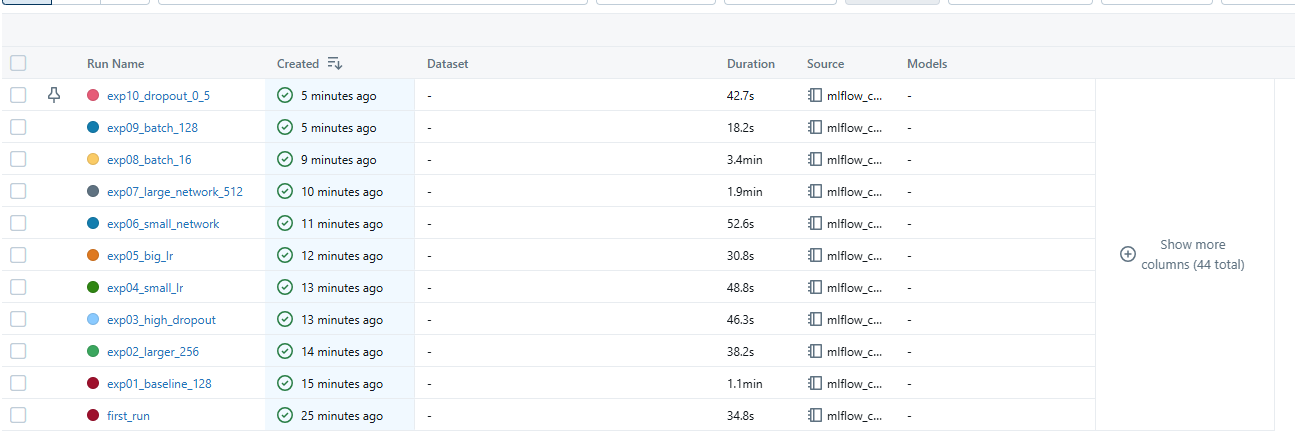

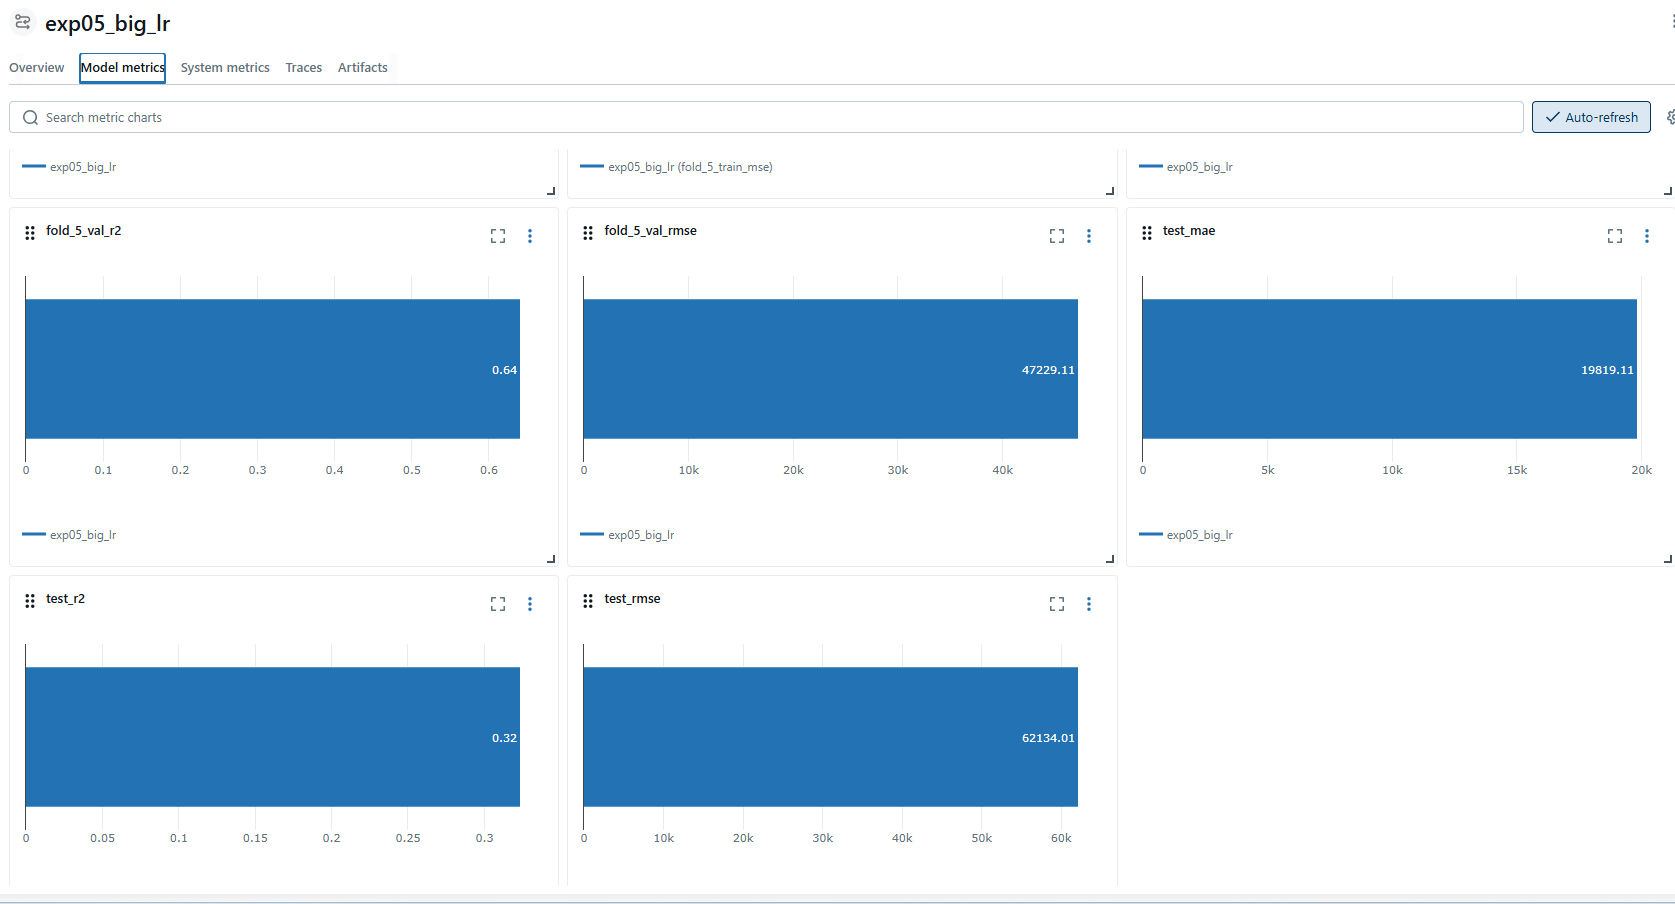

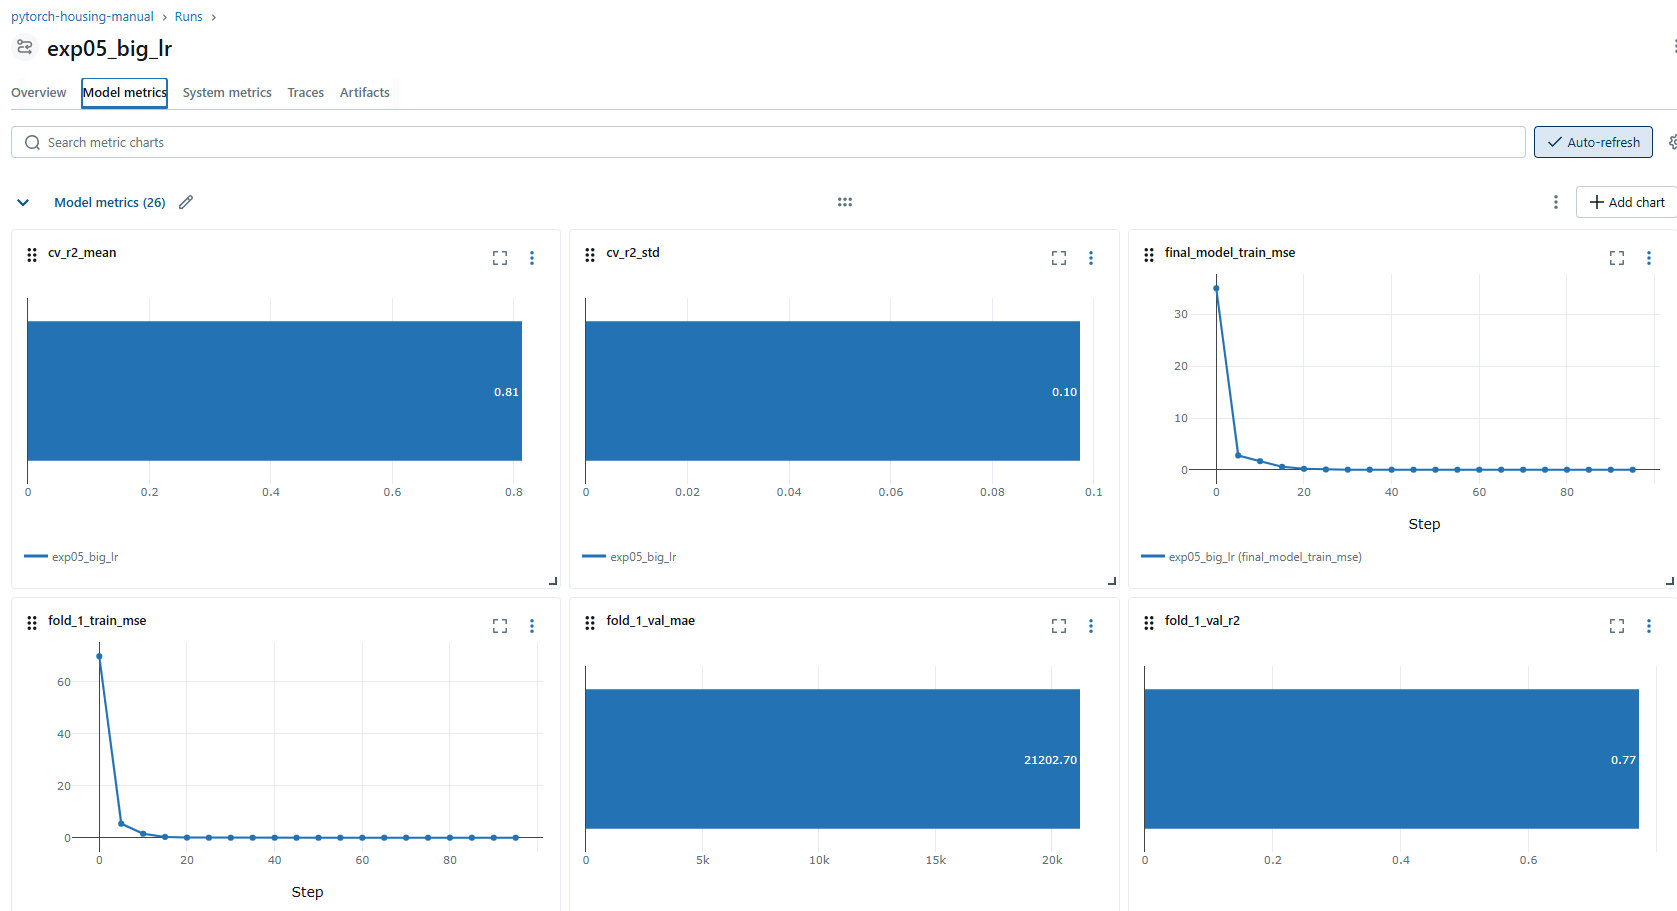

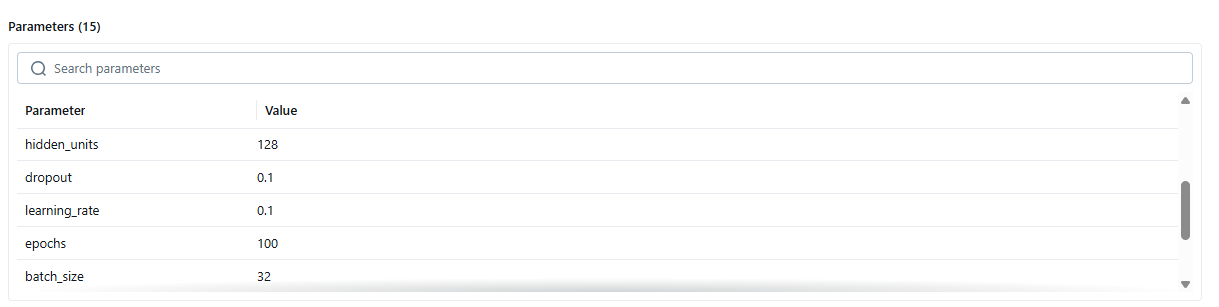

3. Co poprawiło wyniki?
Zmniejszenie learning rate, większa liczba epok i większa liczba neuronów.

Co pogorszyło wyniki?
Zbyt duży learning rate, zbyt mały batch size i zbyt duży dropout

4. W porównaniu do modeli scikit‑learn pierwszy model PyTorch wypadł wyraźnie słabiej i przede wszystkim dużo mniej stabilnie. Modele takie jak Gradient Boosting czy Random Forest osiągały wysokie i powtarzalne wyniki (R² ~0.87–0.90), podczas gdy sieć neuronowa miała testowe R² na poziomie ok. 0.75 i bardzo duże wahania między foldami w cross‑validation. To zachowanie wskazuje na overfitting. Widać to po tym, że wyniki poszczególnych foldów różniły się skrajnie (od ~0.06 do ~0.88), a odchylenie standardowe CV było bardzo wysokie. Model dobrze dopasowywał się do części danych, ale nie potrafił uogólnić tego na inne próbki. To typowe dla MLP trenowanego na małym tablicowym zbiorze danych — bez mocniejszej regularizacji i odpowiedniego doboru hiperparametrów łatwo o przeuczenie.